In [21]:
# 📦 Step 1: Imports
import os
import numpy as np
import json
from PIL import Image
from tqdm import tqdm
from deepface import DeepFace  # Emotion detection
from models.image_captioning import generate_caption  # Custom function
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from joblib import dump

# 🔧 Step 2: Load Models
print("🚀 Loading text embedding model...")
text_model = SentenceTransformer('all-MiniLM-L6-v2')  # 384D embeddings

# 📁 Step 3: Dataset Path
DATASET_PATH = r"C:\Users\shash\OneDrive\Desktop\Main-project\Images"
image_files = [f for f in os.listdir(DATASET_PATH) if f.lower().endswith(('.jpg', '.png'))][:10]

# 📊 Step 4: Flatten Images and Collect Captions
flattened_images = []
image_records = []

print("📸 Processing images...")
for img_name in tqdm(image_files):
    try:
        img_path = os.path.join(DATASET_PATH, img_name)

        # Load and resize
        image = Image.open(img_path).convert('RGB').resize((224, 224))
        img_array = np.array(image).flatten().astype(np.float32)
        flattened_images.append(img_array)

        # Generate caption
        caption = generate_caption(img_path)

        # Detect emotion (DeepFace returns multiple results; pick dominant)
        try:
            emotion_result = DeepFace.analyze(img_path, actions=['emotion'], enforce_detection=False)
            if isinstance(emotion_result, list):
                emotion_result = emotion_result[0]
            dominant_emotion = emotion_result['dominant_emotion']
            emotion_score = emotion_result['emotion'][dominant_emotion]
        except Exception as e:
            dominant_emotion = "neutral"
            emotion_score = 0.0

        image_records.append({
            "image_path": img_path,
            "caption": caption,
            "dominant_emotion": dominant_emotion,
            "emotion_score": float(emotion_score)  # Importance
        })

    except Exception as e:
        print(f"⚠️ Error with {img_name}: {e}")

# 🧠 Step 5: Apply PCA to reduce flattened image to 5D (KEY)
print("🔍 Performing PCA on image data...")
pca = PCA(n_components=5)
pca_image_embeddings = pca.fit_transform(flattened_images)

# 💬 Step 6: Embed captions into 384D (VALUE)
print("💬 Embedding text captions...")
text_captions = [record["caption"] for record in image_records]
caption_embeddings = text_model.encode(text_captions)

# 🧠 Step 7: Build LTM structure
ltm = []
for i in range(len(pca_image_embeddings)):
    ltm.append({
        "key_5d": pca_image_embeddings[i].tolist(),     # KEY
        "caption_384d": caption_embeddings[i].tolist(),       # VALUE
        "caption": image_records[i]["caption"],          # Original text
        "image_path": image_records[i]["image_path"],         # Path
        "dominant_emotion": image_records[i]["dominant_emotion"],
        "emotion_importance": image_records[i]["emotion_score"]
    })

# 💾 Step 8: Save LTM and PCA Model
os.makedirs("long_term_memory", exist_ok=True)
os.makedirs("models", exist_ok=True)

with open("long_term_memory/image_ltm_key_value.json", "w", encoding="utf-8") as f:
    json.dump(ltm, f, indent=2)

dump(pca, "models/pca_image_key_5D.joblib")

print("✅ Long-Term Memory saved: long_term_memory/image_ltm_key_value.json")
print("📦 PCA model saved: models/pca_image_key_5D.joblib")


🚀 Loading text embedding model...
📸 Processing images...


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:16<00:00,  1.67s/it]


🔍 Performing PCA on image data...
💬 Embedding text captions...
✅ Long-Term Memory saved: long_term_memory/image_ltm_key_value.json
📦 PCA model saved: models/pca_image_key_5D.joblib


In [22]:
# 📦 Step 1: Imports
import os
import numpy as np
import json
from tqdm import tqdm
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from joblib import dump
from processors.audio_processor import process_audio  # ✅ use your module

# 🧠 Step 2: Load text embedding model (384D output)
text_model = SentenceTransformer('all-MiniLM-L6-v2')

# 📁 Step 3: Dataset setup
AUDIO_PATH = r"C:\Users\shash\OneDrive\Desktop\Main-project\Audio"
selected_folders = sorted(os.listdir(AUDIO_PATH))[:5]  # Pick first 5 folders

audio_files = []
for folder in selected_folders:
    folder_dir = os.path.join(AUDIO_PATH, folder)
    if not os.path.isdir(folder_dir):
        continue
    folder_audio = sorted([f for f in os.listdir(folder_dir) if f.lower().endswith(".wav")])[:3]
    for file in folder_audio:
        full_path = os.path.join(folder_dir, file)
        audio_files.append(full_path)

print(f"✅ Selected {len(audio_files)} audio files from 5 folders")

# 🔊 Step 4: Extract MFCC features & process audio
audio_features = []
audio_records = []

for path in tqdm(audio_files):
    try:
        # 1️⃣ Process audio to get real caption & emotion
        audio_data = process_audio(path)
        transcribed_caption = audio_data.get("transcribed", "")

        # 2️⃣ Extract MFCC
        y, sr = librosa.load(path, sr=None)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        mfcc_mean = np.mean(mfcc, axis=1)
        audio_features.append(mfcc_mean)

        # 3️⃣ Store record
        audio_records.append({
            "audio_path": path,
            "caption": transcribed_caption,  # ✅ real speech caption
            "emotion": audio_data.get("emotion", "none"),
            "emotion_score": audio_data.get("emotion_score", 0),
            "importance": audio_data.get("importance", 0.7)
        })
    except Exception as e:
        print(f"⚠️ Error processing {path}: {e}")

# 🔍 Step 5: Apply PCA to MFCC features → 5D (key)
print("🔍 Applying PCA to audio features...")
pca = PCA(n_components=5)
pca_audio_embeddings = pca.fit_transform(audio_features)

# 💬 Step 6: Text embedding → 384D
print("💬 Embedding captions using SentenceTransformer...")
captions = [r["caption"] for r in audio_records]
caption_embeddings = text_model.encode(captions)

# 🧠 Step 7: Build Long-Term Memory
ltm_audio = []
for i in range(len(pca_audio_embeddings)):
    ltm_audio.append({
        "key_5d": pca_audio_embeddings[i].tolist(),
        "caption_384d": caption_embeddings[i].tolist(),
        "audio_path": audio_records[i]["audio_path"],
        "caption": audio_records[i]["caption"],
        "emotion": audio_records[i]["emotion"],
        "emotion_score": audio_records[i]["emotion_score"],
        "importance": audio_records[i]["importance"]
    })

# 💾 Step 8: Save LTM and PCA model
os.makedirs("long_term_memory", exist_ok=True)
with open("long_term_memory/audio_ltm.json", "w", encoding="utf-8") as f:
    json.dump(ltm_audio, f, indent=2)

os.makedirs("models", exist_ok=True)
dump(pca, "models/pca_audio_5d.joblib")

print("✅ Audio LTM saved to: long_term_memory/audio_ltm.json")
print("✅ PCA model saved to: models/pca_audio_5d.joblib")


Device set to use cpu


✅ Selected 15 audio files from 5 folders


100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:19<00:00,  1.30s/it]

🔍 Applying PCA to audio features...
💬 Embedding captions using SentenceTransformer...
✅ Audio LTM saved to: long_term_memory/audio_ltm.json
✅ PCA model saved to: models/pca_audio_5d.joblib


In [20]:
# 📦 Step 1: Imports
import os
import json
import numpy as np
from tqdm import tqdm
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import joblib  # for saving PCA model

# 🧠 Step 2: Load models
text_model = SentenceTransformer('all-MiniLM-L6-v2')  # 384D output
emotion_classifier = pipeline(
    "text-classification", 
    model="j-hartmann/emotion-english-distilroberta-base", 
    top_k=1
)

# 📝 Step 3: Sample Text Dataset
text_samples = [
    "I feel so happy today! Everything is perfect.",
    "This is the worst day of my life.",
    "I'm scared about the results.",
    "What a beautiful sunset!",
    "I don't care about this anymore.",
    "You always make me laugh.",
    "That was disgusting!",
    "I’m so excited for the trip.",
    "It’s okay, I guess.",
    "She yelled at me for no reason.",
]

# 📊 Step 4: Collect embeddings before PCA
embeddings_list = []
emotion_list = []

for text in tqdm(text_samples):
    try:
        # Detect emotion
        result = emotion_classifier(text)
        top_result = result[0][0]
        emotion = top_result['label'].lower()
        score = top_result['score']

        # Embed sentence (384D)
        text_embedding = text_model.encode(text)

        embeddings_list.append({
            "caption": text,
            "caption_384d": text_embedding,
            "emotion": emotion,
            "emotion_score": round(score, 3)
        })

    except Exception as e:
        print(f"⚠️ Error processing: {text} → {e}")

# 🌀 Step 5: Fit PCA (reduce to 5D)
pca = PCA(n_components=5)
all_embeddings = np.array([item["caption_384d"] for item in embeddings_list])
embeddings_5d = pca.fit_transform(all_embeddings)

# 💾 Save PCA model
os.makedirs("long_term_memory", exist_ok=True)
joblib.dump(pca, "long_term_memory/text_pca_model_5d.pkl")

# 🗄 Step 6: Add 5D keys to each object
for idx, item in enumerate(embeddings_list):
    item["key_5d"] = embeddings_5d[idx].tolist()
    item["caption_384d"] = item["caption_384d"].tolist()  # Convert to list for JSON

# 💾 Step 7: Save LTM
with open("long_term_memory/text_ltm_with_pca.json", "w", encoding="utf-8") as f:
    json.dump(embeddings_list, f, indent=2)

print("✅ LTM with PCA saved to: long_term_memory/text_ltm_with_pca.json")
print("✅ PCA model saved to: long_term_memory/text_pca_model_5d.pkl")


Device set to use cpu
100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 12.50it/s]

✅ LTM with PCA saved to: long_term_memory/text_ltm_with_pca.json
✅ PCA model saved to: long_term_memory/text_pca_model_5d.pkl


In [12]:
import torch
from PIL import Image
import torchaudio
from transformers import CLIPProcessor, CLIPModel, BlipProcessor, BlipForConditionalGeneration, pipeline
from vosk import Model as VoskModel, KaldiRecognizer
from pydub import AudioSegment
from sklearn.decomposition import PCA
import wave
import json
import os
import numpy as np

# ---------- Setup ----------
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load models
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

emotion_classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", top_k=1)

vosk_model = VoskModel("models/vosk-model-small-en-us-0.15")  # Local path to Vosk model

# ---------- Storage ----------
raw_embeddings = []
metadata = []

# ---------- Image Processing ----------
def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = blip_processor(image, return_tensors="pt").to(device)
    out = blip_model.generate(**inputs)
    return blip_processor.decode(out[0], skip_special_tokens=True)

def process_image(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = clip_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        image_features = clip_model.get_image_features(**inputs)[0]

    caption = generate_caption(image_path)
    emotion = emotion_classifier(caption)[0][0]['label']

    raw_embeddings.append(image_features.cpu().numpy())
    metadata.append({"caption_or_text": caption, "emotion": emotion})

# ---------- Audio Processing ----------
def convert_audio_to_vosk_format(input_path, output_path):
    audio = AudioSegment.from_file(input_path)
    audio = audio.set_channels(1).set_frame_rate(16000)
    audio.export(output_path, format="wav")

def transcribe_audio(audio_path):
    wf = wave.open(audio_path, "rb")
    rec = KaldiRecognizer(vosk_model, wf.getframerate())
    results = []

    while True:
        data = wf.readframes(4000)
        if len(data) == 0:
            break
        if rec.AcceptWaveform(data):
            result = json.loads(rec.Result())
            results.append(result.get("text", ""))
    final_result = json.loads(rec.FinalResult())
    results.append(final_result.get("text", ""))

    return " ".join(results)

def process_audio(original_audio_path):
    converted_path = "temp_audio.wav"
    convert_audio_to_vosk_format(original_audio_path, converted_path)
    
    transcription = transcribe_audio(converted_path)
    
    inputs = clip_processor(text=[transcription], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_features = clip_model.get_text_features(**inputs)[0]

    # NEW (fixed)
    emotion = emotion_classifier(caption)[0][0]['label']

    
    raw_embeddings.append(text_features.cpu().numpy())
    metadata.append({"caption_or_text": transcription, "emotion": emotion})

    # Clean up temp file
    if os.path.exists(converted_path):
        os.remove(converted_path)

# ---------- Text Processing ----------
def process_text(text):
    inputs = clip_processor(text=[text], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_features = clip_model.get_text_features(**inputs)[0]

    emotion = emotion_classifier(text)[0][0]['label']
    raw_embeddings.append(text_features.cpu().numpy())
    metadata.append({"caption_or_text": text, "emotion": emotion})

# ---------- PCA Reduction ----------
def reduce_embeddings():
    all_embeddings = np.vstack(raw_embeddings)
    pca = PCA(n_components=3)
    reduced_embeddings = pca.fit_transform(all_embeddings)

    final_data = []
    for i in range(len(reduced_embeddings)):
        final_data.append({
            "embedding": reduced_embeddings[i].tolist(),
            "caption_or_text": metadata[i]["caption_or_text"],
            "emotion": metadata[i]["emotion"]
        })
    return final_data, reduced_embeddings, pca

# ---------- Example Execution ----------

# Update these paths to point to your files
image_paths = ["C:\\Users\\shash\\OneDrive\\Desktop\\Main-project\\Images\\19212715_20476497a3.jpg", "C:\\Users\\shash\\OneDrive\\Desktop\\Main-project\\Images\\44129946_9eeb385d77.jpg"]
audio_paths = ["C:\\Users\\shash\\OneDrive\\Desktop\\Main-project\\Audio\\Actor_01\\03-01-01-01-01-01-01.wav", "C:\\Users\\shash\\OneDrive\\Desktop\\Main-project\\Audio\\Actor_07\\03-01-02-02-01-01-07.wav"]
text_input = "This is the current text I want to analyze."

for path in image_paths:
    process_image(path)

for path in audio_paths:
    process_audio(path)

process_text(text_input)

final_output, reduced_embeddings, pca = reduce_embeddings()

# Optional: Save or display
import pprint
pprint.pprint(final_output)

# Optionally save to disk
with open("final_output.json", "w") as f:
    json.dump(final_output, f, indent=2)


Device set to use cpu


[{'caption_or_text': 'a person in a kayak pad in the ocean',
  'embedding': [-7.8337321281433105, -4.386822700500488, -0.5726119875907898],
  'emotion': 'fear'},
 {'caption_or_text': 'a couple sitting on a bench',
  'embedding': [-7.317107200622559, 4.480943202972412, 0.9831666350364685],
  'emotion': 'anger'},
 {'caption_or_text': 'kids are talking by the door ',
  'embedding': [4.694247245788574, 0.48464202880859375, -2.3752620220184326],
  'emotion': 'neutral'},
 {'caption_or_text': 'kids are talking by the door ',
  'embedding': [4.694247245788574, 0.4846424162387848, -2.3752620220184326],
  'emotion': 'neutral'},
 {'caption_or_text': 'This is the current text I want to analyze.',
  'embedding': [5.762341499328613, -1.06340754032135, 4.339969158172607],
  'emotion': 'neutral'}]


In [4]:
import joblib
import pickle

# ---------- Save Models and Data ----------
# Save PCA model
joblib.dump(pca, "pca_model.pkl")

# Save reduced embeddings
np.save("reduced_embeddings.npy", reduced_embeddings)

# Save metadata (captions, emotions)
with open("metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)

# Optional: Save raw embeddings (for future retraining or updates)
with open("raw_embeddings.npy", "wb") as f:
    np.save(f, np.array(raw_embeddings))


NameError: name 'reduced_embeddings' is not defined

In [2]:
# multimodal_train.py
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import librosa
import numpy as np
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

# -----------------------------
# Config
# -----------------------------
EMBED_DIM = 15
BATCH_SIZE = 64
LR = 3e-4
EPOCHS = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TEMPERATURE = 0.07
TARGET_FRAMES = 128  # fixed time frames for log-mel
N_MELS = 64
SR = 16000
DATASET_DIR = r"C:\Users\shash\OneDrive\Desktop\Main-project\dataset_triplets"
NUM_WORKERS = 0 if os.name == "nt" else 4

# -----------------------------
# Triplet loader
# -----------------------------
def load_triplets_from_dir(base_dir, max_items=None):
    triplets = []
    for folder in sorted(os.listdir(base_dir)):
        fpath = os.path.join(base_dir, folder)
        if not os.path.isdir(fpath):
            continue
        img = os.path.join(fpath, "image.jpg")
        aud = os.path.join(fpath, "audio.wav")
        cap = os.path.join(fpath, "caption.txt")

        if os.path.exists(img) and os.path.exists(aud) and os.path.exists(cap):
            try:
                with open(cap, "r", encoding="utf-8") as f:
                    text = f.read().strip()
                if len(text) == 0:
                    print(f"⚠️ Empty caption in {folder}, skipping")
                    continue
                triplets.append({"image": img, "text": text, "audio": aud})
            except Exception as e:
                print(f"⚠️ Error reading caption in {folder}: {e}")
        else:
            print(f"⚠️ Missing files in {folder}, skipping...")

        if max_items and len(triplets) >= max_items:
            break

    print(f"✅ Collected {len(triplets)} triplets from {base_dir}")
    return triplets

# -----------------------------
# Dataset
# -----------------------------
class TripletDataset(Dataset):
    def __init__(self, triplets):
        self.items = triplets
        self.img_tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
        ])

    def _load_image(self, path):
        img = Image.open(path).convert("RGB")
        return self.img_tf(img)

    def _load_audio_logmel(self, path):
        y, sr = librosa.load(path, sr=SR)
        if y.shape[0] == 0:
            y = np.zeros(1, dtype=np.float32)
        mel = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=1024, hop_length=512, n_mels=N_MELS)
        # ✅ FIX: correct ref
        mel_db = librosa.power_to_db(mel, ref=np.max)
        t = mel_db.shape[1]
        if t < TARGET_FRAMES:
            pad = TARGET_FRAMES - t
            mel_db = np.pad(mel_db, ((0,0),(0,pad)), mode="constant")
        elif t > TARGET_FRAMES:
            start = (t - TARGET_FRAMES) // 2
            mel_db = mel_db[:, start:start+TARGET_FRAMES]
        m = mel_db.mean()
        s = mel_db.std() + 1e-6
        mel_db = (mel_db - m) / s
        return torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        item = self.items[i]
        img = self._load_image(item["image"])
        txt = item["text"]
        aud = self._load_audio_logmel(item["audio"])
        return img, txt, aud

# -----------------------------
# Encoders
# -----------------------------
class ImageEncoder(nn.Module):
    def __init__(self, out_dim=EMBED_DIM):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        feat_dim = base.fc.in_features
        base.fc = nn.Identity()
        self.backbone = base
        self.proj = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, out_dim)
        )

    def forward(self, x):
        h = self.backbone(x)
        z = F.normalize(self.proj(h), dim=-1)
        return z

class TextEncoder(nn.Module):
    def __init__(self, out_dim=EMBED_DIM, model_name="all-MiniLM-L6-v2"):
        super().__init__()
        self.sbert = SentenceTransformer(model_name)
        in_dim = 384
        self.proj = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, out_dim)
        )

    def forward(self, texts):
        with torch.no_grad():
            emb = self.sbert.encode(texts, convert_to_numpy=True, normalize_embeddings=False)
        emb = torch.tensor(emb, dtype=torch.float32, device=DEVICE)
        z = F.normalize(self.proj(emb), dim=-1)
        return z

class AudioEncoder(nn.Module):
    def __init__(self, out_dim=EMBED_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.proj = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, out_dim)
        )

    def forward(self, x):
        h = self.conv(x).flatten(1)
        z = F.normalize(self.proj(h), dim=-1)
        return z

# -----------------------------
# Losses
# -----------------------------
def pairwise_contrastive_loss(z_a, z_b, temperature=TEMPERATURE):
    z_a = F.normalize(z_a, dim=-1)
    z_b = F.normalize(z_b, dim=-1)
    logits = (z_a @ z_b.t()) / temperature
    labels = torch.arange(z_a.size(0), device=z_a.device)
    loss_ab = F.cross_entropy(logits, labels)
    loss_ba = F.cross_entropy(logits.t(), labels)
    return 0.5 * (loss_ab + loss_ba)

def multimodal_loss(z_img, z_txt, z_aud):
    loss_it = pairwise_contrastive_loss(z_img, z_txt)
    loss_ia = pairwise_contrastive_loss(z_img, z_aud)
    loss_ta = pairwise_contrastive_loss(z_txt, z_aud)
    total = loss_it + loss_ia + loss_ta
    return total, {"it": loss_it.item(), "ia": loss_ia.item(), "ta": loss_ta.item()}

@torch.no_grad()
def alignment_top1(z_a, z_b):
    sims = z_a @ z_b.t()
    preds = sims.argmax(dim=1)
    labels = torch.arange(z_a.size(0), device=z_a.device)
    return (preds == labels).float().mean().item()

# -----------------------------
# Training loop
# -----------------------------
def train(triplets, epochs=EPOCHS):
    ds = TripletDataset(triplets)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(DEVICE!="cpu"))

    img_enc = ImageEncoder().to(DEVICE)
    txt_enc = TextEncoder().to(DEVICE)
    aud_enc = AudioEncoder().to(DEVICE)

    params = list(img_enc.parameters()) + list(txt_enc.proj.parameters()) + list(aud_enc.parameters())
    opt = torch.optim.AdamW(params, lr=LR, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))

    for epoch in range(1, epochs+1):
        img_enc.train(); txt_enc.train(); aud_enc.train()
        running = 0.0
        pbar = tqdm(dl, desc=f"Epoch {epoch}/{epochs}", unit="batch")
        for imgs, texts, auds in pbar:
            imgs = imgs.to(DEVICE, non_blocking=True)
            auds = auds.to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):
                z_img = img_enc(imgs)
                z_txt = txt_enc(texts)
                z_aud = aud_enc(auds)
                loss, parts = multimodal_loss(z_img, z_txt, z_aud)

            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            scaler.step(opt)
            scaler.update()

            running += loss.item()
            avg_loss = running / (pbar.n + 1)
            pbar.set_postfix({"loss": f"{avg_loss:.4f}", **{k: f"{v:.3f}" for k,v in parts.items()}})

        # Eval
        img_enc.eval(); txt_enc.eval(); aud_enc.eval()
        with torch.no_grad():
            try:
                imgs, texts, auds = next(iter(dl))
                imgs = imgs.to(DEVICE); auds = auds.to(DEVICE)
                zi = img_enc(imgs); zt = txt_enc(texts); za = aud_enc(auds)
                acc_it = alignment_top1(zi, zt)
                acc_ia = alignment_top1(zi, za)
                acc_ta = alignment_top1(zt, za)
            except StopIteration:
                acc_it = acc_ia = acc_ta = 0.0

        print(f"Epoch {epoch:02d} | avg_loss {running/len(dl):.4f} | "
              f"it {parts['it']:.4f} ia {parts['ia']:.4f} ta {parts['ta']:.4f} | "
              f"top1 it {acc_it:.3f} ia {acc_ia:.3f} ta {acc_ta:.3f}")

    # Save encoders
    os.makedirs("models", exist_ok=True)
    torch.save(img_enc.state_dict(), "models/img_encoder_15d.pt")
    torch.save(txt_enc.state_dict(), "models/txt_encoder_15d.pt")
    torch.save(aud_enc.state_dict(), "models/aud_encoder_15d.pt")
    print("✅ Saved encoders to models/*.pt")

# -----------------------------
# Entry point
# -----------------------------
if __name__ == "__main__":
    triplets = load_triplets_from_dir(DATASET_DIR, max_items=1000)
    if len(triplets) < 2:
        raise SystemExit("Need at least 2 triplets to train.")
    random.shuffle(triplets)
    if len(triplets) > 1000:
        triplets = triplets[:1000]
    print(f"Starting training on {len(triplets)} triplets, device={DEVICE}")
    train(triplets, epochs=EPOCHS)


✅ Collected 1000 triplets from C:\Users\shash\OneDrive\Desktop\Main-project\dataset_triplets
Starting training on 1000 triplets, device=cpu


C:\Users\shash\AppData\Local\Temp\ipykernel_22132\2331134269.py:207: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))
Epoch 1/10:   0%|                                                                            | 0/16 [00:00<?, ?batch/s]C:\Users\shash\AppData\Local\Temp\ipykernel_22132\2331134269.py:217: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):
Epoch 1/10: 100%|███████████████████████| 16/16 [04:18<00:00, 16.14s/batch, loss=12.8955, it=2.818, ia=3.659, ta=3.695]


Epoch 01 | avg_loss 12.8955 | it 2.8178 ia 3.6586 ta 3.6947 | top1 it 0.156 ia 0.031 ta 0.031


Epoch 2/10: 100%|███████████████████████| 16/16 [03:51<00:00, 14.46s/batch, loss=10.5143, it=1.444, ia=3.549, ta=3.575]


Epoch 02 | avg_loss 10.5143 | it 1.4444 ia 3.5486 ta 3.5746 | top1 it 0.391 ia 0.047 ta 0.047


...

Epoch 08 | avg_loss 6.9758 | it 0.2281 ia 2.8398 ta 2.8903 | top1 it 0.875 ia 0.141 ta 0.141


Epoch 9/10: 100%|████████████████████████| 16/16 [03:13<00:00, 12.12s/batch, loss=6.5713, it=0.225, ia=2.658, ta=2.652]


Epoch 09 | avg_loss 6.5713 | it 0.2255 ia 2.6576 ta 2.6520 | top1 it 0.875 ia 0.078 ta 0.172


Epoch 10/10: 100%|███████████████████████| 16/16 [03:12<00:00, 12.02s/batch, loss=6.2998, it=0.321, ia=2.758, ta=2.299]


Epoch 10 | avg_loss 6.2998 | it 0.3212 ia 2.7577 ta 2.2987 | top1 it 0.828 ia 0.281 ta 0.281
✅ Saved encoders to models/*.pt


In [2]:
import os
import json
import torch
import numpy as np
import time   # 👈 added

from processors.image_processor import process_image
from processors.audio_processor import process_audio
from processors.text_processor import process_text

from multimodal_train import ImageEncoder, AudioEncoder, TextEncoder, DEVICE
from sentence_transformers import SentenceTransformer
from torchvision import transforms
from PIL import Image
import librosa

# --------------------------
# Load trained encoders
# --------------------------
EMBED_DIM = 15
img_enc = ImageEncoder(out_dim=EMBED_DIM).to(DEVICE)
aud_enc = AudioEncoder(out_dim=EMBED_DIM).to(DEVICE)
txt_enc = TextEncoder(out_dim=EMBED_DIM).to(DEVICE)

img_enc.load_state_dict(torch.load("models/img_encoder_15d.pt", map_location=DEVICE))
aud_enc.load_state_dict(torch.load("models/aud_encoder_15d.pt", map_location=DEVICE))
txt_enc.load_state_dict(torch.load("models/txt_encoder_15d.pt", map_location=DEVICE))

img_enc.eval(); aud_enc.eval(); txt_enc.eval()

# Semantic value encoder (384D, frozen)
sem_model = SentenceTransformer("all-MiniLM-L6-v2")

# --------------------------
# Preprocessing
# --------------------------
img_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
])

def load_image(path):
    return img_tf(Image.open(path).convert("RGB")).unsqueeze(0).to(DEVICE)

def load_audio(path, sr=16000, n_mels=64, target_frames=128):
    y, sr = librosa.load(path, sr=sr)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=1024, hop_length=512, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    t = mel_db.shape[1]
    if t < target_frames:
        mel_db = np.pad(mel_db, ((0,0),(0,target_frames-t)), mode="constant")
    elif t > target_frames:
        start = (t - target_frames)//2
        mel_db = mel_db[:, start:start+target_frames]
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std()+1e-6)
    return torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)

# --------------------------
# Build memory entries
# --------------------------
def build_entry(image_path=None, audio_path=None, text_input=None):
    entry = {}

    # Processors (metadata, captions, emotions, etc.)
    if image_path:
        proc = process_image(image_path)
        tensor = load_image(image_path)
        with torch.no_grad():
            key = img_enc(tensor).cpu().numpy().flatten().tolist()
        value = sem_model.encode(proc["caption"]).tolist()
        entry["type"] = "image"
        entry["path"] = image_path
        entry["processor"] = proc
        entry["key"] = key
        entry["value"] = value
        entry["caption"] = proc["caption"]

    if audio_path:
        proc = process_audio(audio_path)
        tensor = load_audio(audio_path)
        with torch.no_grad():
            key = aud_enc(tensor).cpu().numpy().flatten().tolist()
        # For value, use semantic embedding of transcribed text
        value = sem_model.encode(proc["transcribed"]).tolist()
        entry["type"] = "audio"
        entry["path"] = audio_path
        entry["processor"] = proc
        entry["key"] = key
        entry["value"] = value
        entry["caption"] = proc["audio_text"]

    if text_input:
        proc = process_text(text_input)
        with torch.no_grad():
            key = txt_enc([text_input]).cpu().numpy().flatten().tolist()
        value = sem_model.encode(text_input).tolist()
        entry["type"] = "text"
        entry["text"] = text_input
        entry["processor"] = proc
        entry["key"] = key
        entry["value"] = value
        entry["caption"] = proc["text_summary"]

    # 👇 Add timestamp for every entry
    entry["timestamp"] = time.time()

    return entry

# --------------------------
# Example usage
# --------------------------
'''if __name__ == "__main__":
    memory = []

    # 5 demo entries (replace with your actual files/texts)
    memory.append(build_entry(image_path="data/enstein.jpeg"))
    memory.append(build_entry(audio_path="data/einstein_formula.wav"))
    memory.append(build_entry(text_input="Einstein’s famous equation says: energy equals mass times the speed of light squared."))
    memory.append(build_entry(image_path="data/class.jpg"))
    #memory.append(build_entry(image_path="data/667626_18933d713e.jpg"))
    
    #memory.append(build_entry(audio_path="samples/aud2.wav"))

    # Save to JSON
    os.makedirs("memory_store", exist_ok=True)
    with open("memory_store/working_memory.json", "w", encoding="utf-8") as f:
        json.dump(memory, f, indent=4, ensure_ascii=False)

    print("✅ Working memory stored in memory_store/working_memory.json")'''


'if __name__ == "__main__":\n    memory = []\n\n    # 5 demo entries (replace with your actual files/texts)\n    memory.append(build_entry(image_path="data/enstein.jpeg"))\n    memory.append(build_entry(audio_path="data/einstein_formula.wav"))\n    memory.append(build_entry(text_input="Einstein’s famous equation says: energy equals mass times the speed of light squared."))\n    memory.append(build_entry(image_path="data/class.jpg"))\n    #memory.append(build_entry(image_path="data/667626_18933d713e.jpg"))\n\n    #memory.append(build_entry(audio_path="samples/aud2.wav"))\n\n    # Save to JSON\n    os.makedirs("memory_store", exist_ok=True)\n    with open("memory_store/working_memory.json", "w", encoding="utf-8") as f:\n        json.dump(memory, f, indent=4, ensure_ascii=False)\n\n    print("✅ Working memory stored in memory_store/working_memory.json")'

In [11]:
import json
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from multimodal_train import ImageEncoder, AudioEncoder, TextEncoder, DEVICE
from processors.image_processor import process_image
from processors.audio_processor import process_audio
from processors.text_processor import process_text

# ----------------------------
# Load models
# ----------------------------
EMBED_DIM = 15

img_enc = ImageEncoder(out_dim=EMBED_DIM).to(DEVICE)
aud_enc = AudioEncoder(out_dim=EMBED_DIM).to(DEVICE)
txt_enc = TextEncoder(out_dim=EMBED_DIM).to(DEVICE)

img_enc.load_state_dict(torch.load("models/img_encoder_15d.pt", map_location=DEVICE))
aud_enc.load_state_dict(torch.load("models/aud_encoder_15d.pt", map_location=DEVICE))
txt_enc.load_state_dict(torch.load("models/txt_encoder_15d.pt", map_location=DEVICE))

img_enc.eval(); aud_enc.eval(); txt_enc.eval()

sem_model = SentenceTransformer("all-MiniLM-L6-v2")

# ----------------------------
# cosine similarity
# ----------------------------
def cos_sim(a, b):
    a = np.array(a); b = np.array(b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))

# ----------------------------
# Build query embeddings (15D key + 384D value)
# ----------------------------
def build_query(image=None, audio=None, text=None):
    result = {
        "key": [],
        "value": [],
        "query_text": ""
    }

    # ----------------------
    # IMAGE QUERY
    # ----------------------
    if image:
        proc = process_image(image)          # returns caption
        tensor = load_image(image)           # correctly load image tensor
        
        with torch.no_grad():
            key = img_enc(tensor).cpu().numpy().flatten()

        value = sem_model.encode(proc["caption"])

        result["key"].append(key)
        result["value"].append(value)
        result["query_text"] += proc["caption"] + " "

    # ----------------------
    # AUDIO QUERY
    # ----------------------
    if audio:
        proc = process_audio(audio)          # returns transcript
        tensor = load_audio(audio)           # correctly load mel tensor
        
        with torch.no_grad():
            key = aud_enc(tensor).cpu().numpy().flatten()

        value = sem_model.encode(proc["transcribed"])

        result["key"].append(key)
        result["value"].append(value)
        result["query_text"] += proc["transcribed"] + " "

    # ----------------------
    # TEXT QUERY
    # ----------------------
    if text:
        proc = process_text(text)

        with torch.no_grad():
            key = txt_enc([text]).cpu().numpy().flatten()

        value = sem_model.encode(text)

        result["key"].append(key)
        result["value"].append(value)
        result["query_text"] += text

    return result



# ----------------------------
# Load memory JSON directly
# ----------------------------
with open("memory_store/working_memory.json", "r", encoding="utf-8") as f:
    memory = json.load(f)


# ----------------------------
# TOP-N RETRIEVAL
# ----------------------------
def topn_retrieval(query, top_n=5, alpha=0.5):
    results = []

    for item in memory:
        sv = cos_sim(query["value"][0], item["value"])
        sk = cos_sim(query["key"][0], item["key"])
        score = (1 - alpha) * sv + alpha * sk

        results.append({
            "caption": item["caption"],
            "score": score,
            "sim_value": sv,
            "sim_key": sk
        })

    results.sort(key=lambda x: x["score"], reverse=True)
    return results[:top_n]



# ----------------------------
# Accuracy (semantic similarity)
# ----------------------------
def compute_accuracy(query_text, retrieved):
    q = sem_model.encode(query_text)
    sims = []

    for r in retrieved:
        cap = r["caption"]
        vec = sem_model.encode(cap)
        sims.append(cos_sim(q, vec))

    sims = np.array(sims)
    return {
        "mean": float(sims.mean()),
        "std": float(sims.std()),
        "scores": sims.tolist()
    }


# ----------------------------
# RUN EXPERIMENT
# ----------------------------
if __name__ == "__main__":
    # Example input
    q = build_query(
        
        audio="blind3.wav",
        text="Summarize the concept in one sentence."
    )

    retrieved = topn_retrieval(q, top_n=5)
    acc = compute_accuracy(q["query_text"], retrieved)

    output = {
        "query": q["query_text"],
        "retrieved": retrieved,
        "accuracy": acc
    }

    # Save
    with open("evaluation/retrieval_result_input3.json", "w", encoding="utf-8") as f:
        json.dump(output, f, indent=4, ensure_ascii=False)

    print("✅ Saved → evaluation1/retrieval_result_input2.json")


✅ Saved → evaluation1/retrieval_result_input2.json


In [6]:
import json

with open("knowledge/real_world_facts.json") as f:
    facts = json.load(f)

fact_keys = list(facts.keys())
fact_texts = list(facts.values())


In [2]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")


In [3]:
import torch

fact_embeddings = model.encode(
    fact_texts,
    convert_to_tensor=True,   # keeps tensors for similarity search
    normalize_embeddings=True # ensures vectors are unit length
)


In [4]:
torch.save({
    "keys": fact_keys,
    "texts": fact_texts,
    "embeddings": fact_embeddings
}, "knowledge/real_world_facts.pt")


In [11]:
import torch
from sentence_transformers import util

# Load precomputed embeddings
data = torch.load("knowledge/real_world_facts.pt")
fact_keys, fact_texts, fact_embeddings = data["keys"], data["texts"], data["embeddings"]

def retrieve_facts(query, top_k=3):
    query_emb = model.encode(query, convert_to_tensor=True, normalize_embeddings=True)
    scores = util.cos_sim(query_emb, fact_embeddings)[0]
    best_idx = torch.topk(scores, k=top_k).indices.tolist()
    return [(fact_keys[i], fact_texts[i], float(scores[i])) for i in best_idx]

# Example
print(retrieve_facts("Conduction", top_k=3))


[('Conduction', 'Metals are good conductors of heat.', 0.4530546963214874), ('Electricity', 'Current flows when there is potential difference.', 0.3802034854888916), ('Inertia', 'Objects resist changes in their motion.', 0.2963930368423462)]


In [26]:
import json
import os

def load_knowledge():
    files = [
        "knowledge/physics_constants.json",
        "knowledge/physics_formulas.json",
        "knowledge/physics_laws.json",
        "knowledge/math_constants.json",
        "knowledge/math_formulas.json",
        "knowledge/math_laws.json",
        "knowledge/real_world_facts.json"
    ]
    
    knowledge = {}
    for f in files:
        with open(f, "r") as fp:
            data = json.load(fp)

            if isinstance(data, dict):
                # ✅ Direct dict → add directly
                knowledge.update(data)

            elif isinstance(data, list):
                # ✅ List of objects → flatten into key → statement
                for item in data:
                    if isinstance(item, dict):
                        # Use "name" if exists, else fallback to first key
                        if "name" in item and "statement" in item:
                            knowledge[item["name"]] = item["statement"]
                        elif "name" in item:
                            knowledge[item["name"]] = str(item)
                        else:
                            # Auto-generate a key
                            key = f"{f}_{len(knowledge)}"
                            knowledge[key] = str(item)
                    elif isinstance(item, list) and len(item) == 2:
                        # ✅ Handle [["key","value"], ...]
                        knowledge[item[0]] = item[1]

            else:
                raise ValueError(f"Unsupported format in {f}: {type(data)}")

    return knowledge


In [21]:
from sentence_transformers import SentenceTransformer
import numpy as np
import json, glob, os

# -------------------------------
# Load embedding model
# -------------------------------
model = SentenceTransformer("all-MiniLM-L6-v2")

# -------------------------------
# Load knowledge from JSON
# -------------------------------
def load_knowledge(base_path="./knowledge"):
    facts, knowledge = {}, {}
    for file in glob.glob(os.path.join(base_path, "*.json")):
        with open(file, "r", encoding="utf-8") as f:  # force UTF-8
            data = json.load(f)
            if isinstance(data, dict):   # facts
                facts.update(data)
            elif isinstance(data, list): # knowledge
                for item in data:
                    if "name" in item:
                        knowledge[item["name"]] = item
    return facts, knowledge

# -------------------------------
# Embed texts
# -------------------------------
def embed_texts(texts):
    return model.encode(texts, normalize_embeddings=True)

# -------------------------------
# Build search index
# -------------------------------
def build_index(facts, knowledge):
    fact_keys, fact_texts = list(facts.keys()), list(facts.values())
    know_keys, know_texts = list(knowledge.keys()), [k["statement"] for k in knowledge.values()]

    fact_emb = embed_texts(fact_texts)
    know_emb = embed_texts(know_texts)

    return fact_keys, fact_texts, fact_emb, know_keys, list(knowledge.values()), know_emb

# -------------------------------
# Search function
# -------------------------------
def search(query, fact_keys, fact_texts, fact_emb, know_keys, know_items, know_emb, top_n=3, threshold=0.4):
    q_emb = embed_texts([query])[0]

    # Cosine similarity
    fact_scores = np.dot(fact_emb, q_emb)
    know_scores = np.dot(know_emb, q_emb)

    fact_idx = np.argsort(-fact_scores)[:top_n]
    know_idx = np.argsort(-know_scores)[:top_n]

    facts_res = [{fact_keys[i]: fact_texts[i]} for i in fact_idx if fact_scores[i] > threshold]
    know_res = [{know_keys[i]: know_items[i]} for i in know_idx if know_scores[i] > threshold]

    return {"facts": facts_res, "knowledge": know_res}

# -------------------------------
# Pretty print results
# -------------------------------
def print_results(query, result):
    print(f"\n🔍 Query: {query}")

    # Facts
    print("👉 Facts:")
    if result["facts"]:
        for f in result["facts"]:
            for k, v in f.items():
                print(f"   • {k}: {v}")
    else:
        print("   • None")

    # Knowledge
    print("👉 Knowledge:")
    if result["knowledge"]:
        for k in result["knowledge"]:
            for name, item in k.items():
                print(f"   • {name}")
                if "statement" in item:
                    print(f"      ↪ Statement: {item['statement']}")
                if "formula" in item:
                    print(f"      ↪ Formula: {item['formula']}")
                if "explanation" in item:
                    print(f"      ↪ Explanation: {item['explanation']}")
                if "example" in item:
                    print(f"      ↪ Example: {item['example']}")
    else:
        print("   • None")

# -------------------------------
# Example usage
# -------------------------------
if __name__ == "__main__":
    facts, knowledge = load_knowledge("./knowledge")
    fact_keys, fact_texts, fact_emb, know_keys, know_items, know_emb = build_index(facts, knowledge)

    queries = ["energy mass relation", "force formula", "triangle rule", "gravity"]

    for q in queries:
        res = search(q, fact_keys, fact_texts, fact_emb, know_keys, know_items, know_emb)
        print_results(q, res)



🔍 Query: energy mass relation
👉 Facts:
   • E=mc^2: Energy equals mass times the square of the speed of light.
👉 Knowledge:
   • Einstein’s Mass-Energy Equivalence
      ↪ Statement: Mass and energy are interchangeable; the total energy of an object is equal to its mass multiplied by the speed of light squared.
      ↪ Formula: E = m * c^2
      ↪ Explanation: This principle from Einstein's theory of relativity shows that a small amount of mass can be converted into a huge amount of energy. It underlies nuclear reactions in stars and reactors.
      ↪ Example: In nuclear fusion inside the Sun, hydrogen nuclei fuse into helium, releasing energy because a tiny fraction of mass is converted into radiant energy.
   • Universal Law of Gravitation
      ↪ Statement: Every mass attracts every other mass with a force proportional to the product of their masses and inversely proportional to the square of the distance between them.
      ↪ Formula: F = G * (m1 * m2) / r^2
      ↪ Explanation: T

In [27]:
# ----------------------------------
# build_knowledge_pt.py
# ----------------------------------
import torch
import json
import glob
import os
from sentence_transformers import SentenceTransformer

# -------------------------------
# Load embedding model
# -------------------------------
model = SentenceTransformer("all-MiniLM-L6-v2")

# -------------------------------
# Load all JSON knowledge
# -------------------------------
def load_knowledge(base_path="./knowledge"):
    facts, knowledge = {}, {}
    for file in glob.glob(os.path.join(base_path, "*.json")):
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)
            if isinstance(data, dict):   # facts
                facts.update(data)
            elif isinstance(data, list): # knowledge
                for item in data:
                    if "name" in item:
                        knowledge[item["name"]] = item
    return facts, knowledge

# -------------------------------
# Embed a list of texts
# -------------------------------
def embed_texts(texts):
    return model.encode(texts, normalize_embeddings=True)

# -------------------------------
# Build index and save as .pt
# -------------------------------
def build_and_save_pt(facts, knowledge, save_path="knowledge/knowledge_embeddings.pt"):
    # Facts
    fact_keys, fact_texts = list(facts.keys()), list(facts.values())
    fact_emb = embed_texts(fact_texts)
    fact_emb = torch.tensor(fact_emb)

    # Knowledge
    know_keys, know_items = list(knowledge.keys()), list(knowledge.values())
    know_texts = [k["statement"] if "statement" in k else str(k) for k in know_items]
    know_emb = embed_texts(know_texts)
    know_emb = torch.tensor(know_emb)

    # Save all in one file
    torch.save({
        "fact_keys": fact_keys,
        "fact_texts": fact_texts,
        "fact_emb": fact_emb,
        "know_keys": know_keys,
        "know_items": know_items,
        "know_emb": know_emb
    }, save_path)
    print(f"✅ Knowledge and embeddings saved to {save_path}")

# -------------------------------
# Main
# -------------------------------
if __name__ == "__main__":
    facts, knowledge = load_knowledge("./knowledge")
    build_and_save_pt(facts, knowledge, save_path="knowledge/knowledge_embeddings.pt")


✅ Knowledge and embeddings saved to knowledge/knowledge_embeddings.pt


In [28]:
# ----------------------------------
# output_layer.py
# ----------------------------------
import torch
import numpy as np
from sentence_transformers import SentenceTransformer, util
import os

class OutputLayer:
    def __init__(self, knowledge_path="knowledge/knowledge_embeddings.pt", threshold=0.4):
        """
        Initialize OutputLayer with precomputed embeddings.
        knowledge_path: path to the .pt file storing facts + knowledge embeddings
        """
        self.threshold = threshold
        self.model = SentenceTransformer("all-MiniLM-L6-v2")
        self._load_knowledge(knowledge_path)

    # -------------------------------
    # Load facts and knowledge from .pt
    # -------------------------------
    def _load_knowledge(self, path):
        if not os.path.exists(path):
            raise FileNotFoundError(f"Embeddings file not found: {path}")
        data = torch.load(path)

        # Facts
        self.fact_keys = data.get("fact_keys", [])
        self.fact_texts = data.get("fact_texts", [])
        self.fact_emb = data.get("fact_emb", torch.tensor([])).cpu().numpy()

        # Knowledge
        self.know_keys = data.get("know_keys", [])
        self.know_items = data.get("know_items", [])
        self.know_emb = data.get("know_emb", torch.tensor([])).cpu().numpy()

    # -------------------------------
    # Retrieve top facts using semantic similarity
    # -------------------------------
    def retrieve_facts(self, query, top_k=3):
        query_emb = self.model.encode(query, convert_to_tensor=True, normalize_embeddings=True)
        scores = util.cos_sim(query_emb, torch.tensor(self.fact_emb))
        best_idx = torch.topk(scores[0], k=top_k).indices.tolist()
        return [(self.fact_keys[i], self.fact_texts[i], float(scores[0][i])) for i in best_idx]

    # -------------------------------
    # Search combined facts + knowledge
    # -------------------------------
    def search(self, query, top_n=3):
        q_emb = self.model.encode([query], normalize_embeddings=True)[0]

        # Cosine similarity for facts
        fact_scores = np.dot(self.fact_emb, q_emb) if self.fact_emb.size > 0 else np.array([])

        # Cosine similarity for knowledge
        know_scores = np.dot(self.know_emb, q_emb) if self.know_emb.size > 0 else np.array([])

        # Top indices
        fact_idx = np.argsort(-fact_scores)[:top_n] if fact_scores.size > 0 else []
        know_idx = np.argsort(-know_scores)[:top_n] if know_scores.size > 0 else []

        # Thresholded results
        facts_res = [{self.fact_keys[i]: self.fact_texts[i]} for i in fact_idx if fact_scores[i] > self.threshold]
        know_res = [{self.know_keys[i]: self.know_items[i]} for i in know_idx if know_scores[i] > self.threshold]

        return {"facts": facts_res, "knowledge": know_res}

    # -------------------------------
    # Pretty formatting
    # -------------------------------
    def format_output(self, query, result):
        output_lines = [f"\n🔍 Query: {query}"]

        # Facts
        output_lines.append("👉 Facts:")
        if result["facts"]:
            for f in result["facts"]:
                for k, v in f.items():
                    output_lines.append(f"   • {k}: {v}")
        else:
            output_lines.append("   • None")

        # Knowledge
        output_lines.append("👉 Knowledge:")
        if result["knowledge"]:
            for k in result["knowledge"]:
                for name, item in k.items():
                    output_lines.append(f"   • {name}")
                    if isinstance(item, dict):
                        if "statement" in item:
                            output_lines.append(f"      ↪ Statement: {item['statement']}")
                        if "formula" in item:
                            output_lines.append(f"      ↪ Formula: {item['formula']}")
                        if "explanation" in item:
                            output_lines.append(f"      ↪ Explanation: {item['explanation']}")
                        if "example" in item:
                            output_lines.append(f"      ↪ Example: {item['example']}")
                    else:
                        output_lines.append(f"      ↪ {item}")
        else:
            output_lines.append("   • None")

        return "\n".join(output_lines)

    # -------------------------------
    # Full pipeline
    # -------------------------------
    def run(self, query, top_n=3):
        result = self.search(query, top_n=top_n)
        pretty = self.format_output(query, result)
        return result, pretty


# -------------------------------
# Example usage
# -------------------------------
if __name__ == "__main__":
    layer = OutputLayer("knowledge/knowledge_embeddings.pt")
    queries = ["energy mass relation", "force formula", "triangle rule", "gravity"]
    for q in queries:
        res, pretty = layer.run(q, top_n=3)
        print(pretty)



🔍 Query: energy mass relation
👉 Facts:
   • E=mc^2: Energy equals mass times the square of the speed of light.
👉 Knowledge:
   • Einstein’s Mass-Energy Equivalence
      ↪ Statement: Mass and energy are interchangeable; the total energy of an object is equal to its mass multiplied by the speed of light squared.
      ↪ Formula: E = m * c^2
      ↪ Explanation: This principle from Einstein's theory of relativity shows that a small amount of mass can be converted into a huge amount of energy. It underlies nuclear reactions in stars and reactors.
      ↪ Example: In nuclear fusion inside the Sun, hydrogen nuclei fuse into helium, releasing energy because a tiny fraction of mass is converted into radiant energy.
   • Universal Law of Gravitation
      ↪ Statement: Every mass attracts every other mass with a force proportional to the product of their masses and inversely proportional to the square of the distance between them.
      ↪ Formula: F = G * (m1 * m2) / r^2
      ↪ Explanation: T

In [1]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load a pretrained transformer model for sentence embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')

image_caption = "a diagram explaining mass energy equivalence"
audio_transcript = "einstein explained that mass and energy are related"
text_query = "explain einstein mass energy formula"

# Encode to embeddings
X = model.encode(image_caption)
Y = model.encode(audio_transcript)
Z = model.encode(text_query)

print("Image Embedding Shape:", X.shape)
print("Audio Embedding Shape:", Y.shape)
print("Text Embedding Shape:", Z.shape)



Image Embedding Shape: (384,)
Audio Embedding Shape: (384,)
Text Embedding Shape: (384,)


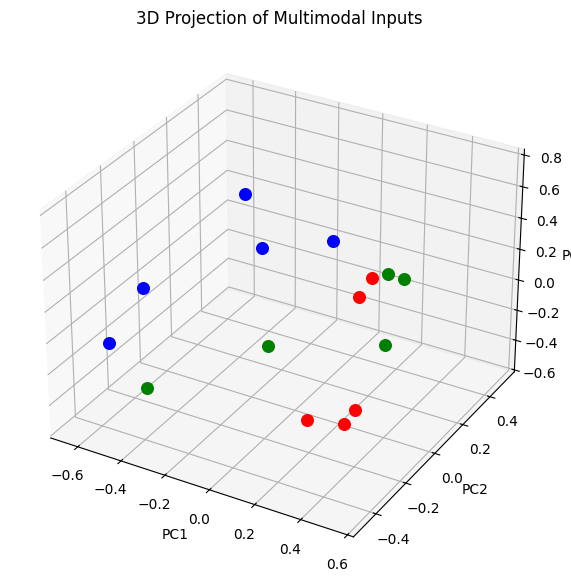

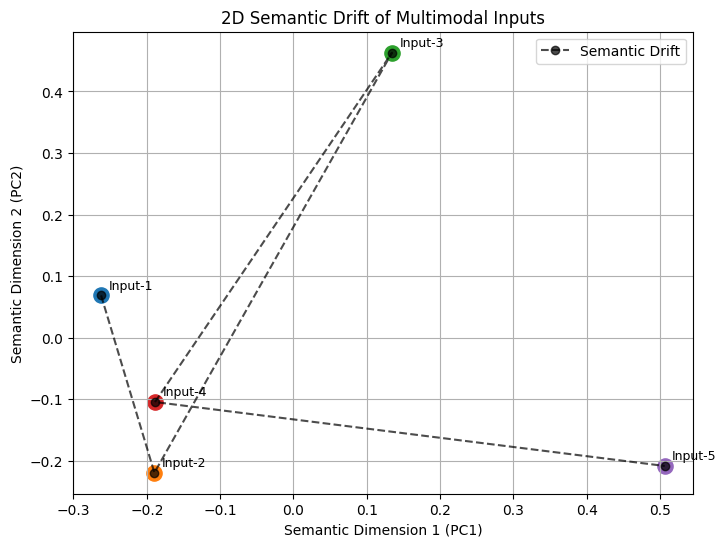


--- 2D Semantic Centroid Coordinates ---
Input-1: X=-0.2624, Y=0.0688
Input-2: X=-0.1896, Y=-0.2191
Input-3: X=0.1344, Y=0.4628
Input-4: X=-0.1888, Y=-0.1043
Input-5: X=0.5064, Y=-0.2081

--- PCA Explained Variance (2D) ---
[0.40377116 0.31245184]
Total Variance Captured: 0.716223


In [8]:
# ==========================================================
# 1. Imports
# ==========================================================
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# ==========================================================
# 2. Load Sentence Transformer Model
# ==========================================================
model = SentenceTransformer("all-MiniLM-L6-v2")


# ==========================================================
# 3. Temporal / Sequential Multimodal Queries
# ==========================================================
annual_queries = {
    "Input-1": {
        "image": "a diagram showing a physics formula",
        "audio": "energy equals mass times speed of light squared",
        "text":  "what is e equals mc square"
    },
    "Input-2": {
        "image": "diagram explaining mass energy equivalence",
        "audio": "einstein explained mass energy relation",
        "text":  "explain einstein mass energy formula"
    },
    "Input-3": {
        "image": "nuclear reaction energy release diagram",
        "audio": "nuclear reactions convert mass into energy",
        "text":  "how is e equals mc square used in nuclear energy"
    },
    "Input-4": {
        "image": "relativistic energy momentum graph",
        "audio": "mass energy equivalence explains relativity",
        "text":  "derive e equals mc square"
    },
    "Input-5": {
        "image": "stellar fusion illustration",
        "audio": "stars generate energy through fusion",
        "text":  "role of mass energy equivalence in astrophysics"
    }
}


# ==========================================================
# 4. Encode All Modalities (Global PCA Fit)
# ==========================================================
all_embeddings = []

for q in annual_queries.values():
    all_embeddings.extend([
        model.encode(q["image"]),
        model.encode(q["audio"]),
        model.encode(q["text"])
    ])

all_embeddings = np.vstack(all_embeddings)


# ==========================================================
# 5. PCA → 3D Projection (Shared Space)
# ==========================================================
pca_3d = PCA(n_components=3)
pca_3d.fit(all_embeddings)


# ==========================================================
# 6. 3D Scatter Plot (Each Modality, No Connections)
# ==========================================================
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

colors = {"image": "blue", "audio": "green", "text": "red"}

for label, q in annual_queries.items():
    for modality in ["image", "audio", "text"]:
        emb = model.encode(q[modality])
        point = pca_3d.transform([emb])[0]
        ax.scatter(*point, color=colors[modality], s=70)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Projection of Multimodal Inputs")
plt.show()


# ==========================================================
# 7. Compute Centroid per Input
# ==========================================================
centroids = []
labels = []

for label, q in annual_queries.items():
    img = model.encode(q["image"])
    aud = model.encode(q["audio"])
    txt = model.encode(q["text"])

    centroid = np.mean([img, aud, txt], axis=0)
    centroids.append(centroid)
    labels.append(label)

centroids = np.vstack(centroids)


# ==========================================================
# 8. PCA → 2D Projection (Centroids Only)
# ==========================================================
pca_2d = PCA(n_components=2)
centroids_2d = pca_2d.fit_transform(centroids)


# ==========================================================
# 9. 2D Semantic Drift Plot (WITH LINE)
# ==========================================================
plt.figure(figsize=(8, 6))

plt.plot(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    linestyle="--",
    marker="o",
    color="black",
    alpha=0.7,
    label="Semantic Drift"
)

for i, label in enumerate(labels):
    plt.scatter(centroids_2d[i, 0], centroids_2d[i, 1], s=120)
    plt.text(
        centroids_2d[i, 0] + 0.01,
        centroids_2d[i, 1] + 0.01,
        label,
        fontsize=9
    )

plt.xlabel("Semantic Dimension 1 (PC1)")
plt.ylabel("Semantic Dimension 2 (PC2)")
plt.title("2D Semantic Drift of Multimodal Inputs")
plt.grid(True)
plt.legend()
plt.show()


# ==========================================================
# 10. Console Outputs (For Thesis / Report)
# ==========================================================
print("\n--- 2D Semantic Centroid Coordinates ---")
for lbl, c in zip(labels, centroids_2d):
    print(f"{lbl}: X={c[0]:.4f}, Y={c[1]:.4f}")

print("\n--- PCA Explained Variance (2D) ---")
print(pca_2d.explained_variance_ratio_)
print("Total Variance Captured:", pca_2d.explained_variance_ratio_.sum())


In [4]:
from sklearn.decomposition import PCA

# Stack all three modality embeddings
embeddings = np.vstack([X, Y, Z])

# Fit PCA to reduce from 384 → 3 dimensions
pca = PCA(n_components=3)
reduced_embeddings = pca.fit_transform(embeddings)

# Assign back to variables
X_3d, Y_3d, Z_3d = reduced_embeddings

print("🖼️ Image (X):", X_3d)
print("🔊 Audio (Y):", Y_3d)
print("📝 Text (Z):", Z_3d)


🖼️ Image (X): [-6.6646993e-01  2.2593319e-01 -1.1095986e-07]
🔊 Audio (Y): [ 9.3176797e-02 -5.8340776e-01 -1.1095980e-07]
📝 Text (Z): [ 5.73293388e-01  3.57474416e-01 -1.10959824e-07]


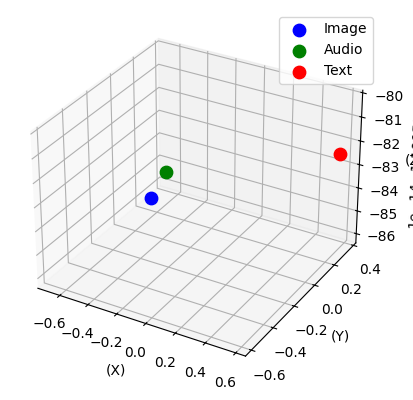

In [24]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Modality input points
ax.scatter(*X_3d, color='blue', s=80, label='Image')
ax.scatter(*Y_3d, color='green', s=80, label='Audio')
ax.scatter(*Z_3d, color='red', s=80, label='Text')

# Add later: agent reasoning points (Normal, Blind, Mute)

ax.set_xlabel('(X)')
ax.set_ylabel('(Y)')
ax.set_zlabel('(Z)')
ax.legend()
plt.show()


=== 3D Reasoning Embedding Coordinates ===
Normal Agent: (x=0.4891, y=-0.3844, z=0.0000)
Blind Agent: (x=0.4099, y=0.4077, z=0.0000)
Mute Agent: (x=-0.8990, y=-0.0233, z=0.0000)

Normal Agent is closer to: Blind Agent
→ Distance to Blind Agent: 0.7961
→ Distance to Mute Agent: 1.4343


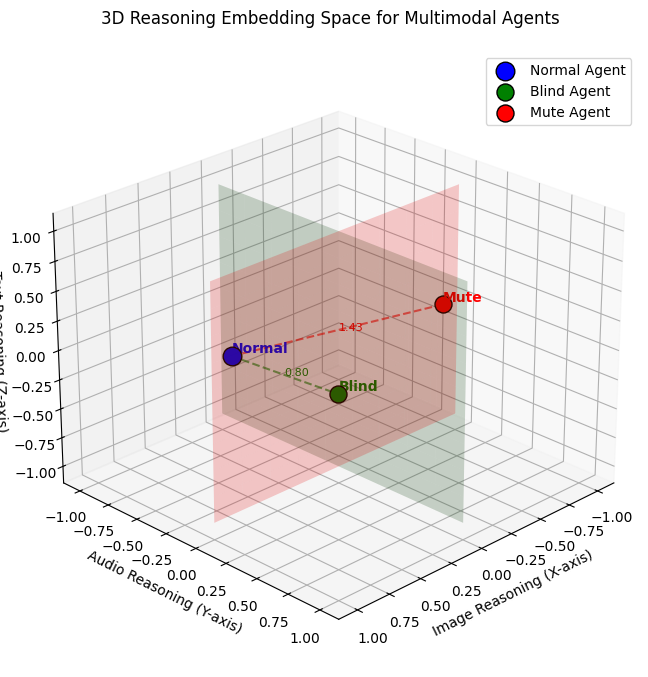

In [17]:
# === Neuro-Adaptive Reasoning 3D Embedding Visualization ===
# Author: Shashi Madari & Team
# Purpose: Visualize reasoning embeddings of three multimodal agents in 3D reasoning space.

from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- Load the model ---
model = SentenceTransformer('all-MiniLM-L6-v2')

# --- Reasoning Sentences for each Agent ---
reasoning_normal = '''When one object *pushes* or *pulls* on another, it's not a one-sided interaction. Instead, a force is immediately *generated* in the opposite direction, acting back on the first object. Think of it like a dynamic exchange: if my hand *applies* a force to a ball, the ball doesn't just passively receive it; it *responds* by applying an equal and opposite force back onto my hand. This isn't a sequence of events, but rather a simultaneous, interwoven action and reaction, always occurring together.

This pairing of forces has specific characteristics. The "action" force and the "reaction" force are always *equal in magnitude*, meaning they have the same strength or intensity. They are also always *opposite in direction*, pushing or pulling away from each other along the same line. A critical point to grasp is that these forces *act on different objects*. My hand pushes the ball, and the ball pushes my hand. If they acted on the same object, they would simply cancel each other out, and no motion would ever occur. Because they act on separate entities, they can each influence the motion of their respective object.

Consider a rocket launching into space. The rocket *expels* hot gases downward with immense force. This downward "action" force on the gases *causes* an upward "reaction" force on the rocket itself. It's this upward push from the expelled gases that *propels* the rocket off the launchpad and into the sky. Similarly, when you walk, your foot *pushes* backward on the ground. The ground, in turn, *pushes* forward on your foot, *enabling* your forward movement. Without that ground reaction, you'd simply slip.

So, Newton's Third Law isn't just a static statement; it describes the fundamental, interactive dance of forces that governs all physical interactions. Every time something *exerts* a force, another force is *generated* in response, shaping the motion and behavior of everything around us.




'''

reasoning_blind = '''Newton's Third Law of Motion describes a fundamental principle of interaction: forces never exist in isolation. When one object *exerts* a force upon a second object, that second object *simultaneously* generates an equal and opposite force acting back upon the first. This means that every "action" force immediately triggers a "reaction" force, creating an inseparable pair. The action force doesn't happen first, followed by a reaction; they are born together in the moment of interaction


'''

reasoning_mute = '''No reasoning

"'''

# --- Encode reasoning embeddings ---
f_normal = model.encode(reasoning_normal)
f_blind = model.encode(reasoning_blind)
f_mute = model.encode(reasoning_mute)

# Combine embeddings
embeddings = np.vstack([f_normal, f_blind, f_mute])

# --- Reduce to 3D using PCA ---
pca = PCA(n_components=3)
reduced = pca.fit_transform(embeddings)

# Extract coordinates
x, y, z = reduced[:, 0], reduced[:, 1], reduced[:, 2]
agents = ['Normal Agent', 'Blind Agent', 'Mute Agent']

# --- Print 3D coordinates ---
print("=== 3D Reasoning Embedding Coordinates ===")
for i, name in enumerate(agents):
    print(f"{name}: (x={x[i]:.4f}, y={y[i]:.4f}, z={z[i]:.4f})")

# --- Compute distances from Normal Agent to others ---
dist_blind = np.linalg.norm(reduced[0] - reduced[1])
dist_mute = np.linalg.norm(reduced[0] - reduced[2])

closest = "Mute Agent" if dist_mute < dist_blind else "Blind Agent"
print(f"\nNormal Agent is closer to: {closest}")
print(f"→ Distance to Blind Agent: {dist_blind:.4f}")
print(f"→ Distance to Mute Agent: {dist_mute:.4f}")

# --- Plot 3D reasoning space ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# === 1️⃣ Normal Agent (Full modality reasoning) ===
ax.scatter(x[0], y[0], z[0], s=180, color='blue', label='Normal Agent', edgecolor='k')
ax.text(x[0], y[0], z[0]+0.03, "Normal", color='blue', fontsize=10, weight='bold')

# === 2️⃣ Blind Agent (Audio-Text plane → Y–Z) ===
y_plane = np.linspace(-1, 1, 10)
z_plane = np.linspace(-1, 1, 10)
Yb, Zb = np.meshgrid(y_plane, z_plane)
Xb = np.full_like(Yb, np.mean(x))  # No visual input
ax.plot_surface(Xb, Yb, Zb, color='green', alpha=0.2)
ax.scatter(x[1], y[1], z[1], s=150, color='green', label='Blind Agent', edgecolor='k')
ax.text(x[1], y[1], z[1]+0.03, "Blind", color='green', fontsize=10, weight='bold')

# === 3️⃣ Mute Agent (Image-Text plane → X–Z) ===
x_plane = np.linspace(-1, 1, 10)
z_plane = np.linspace(-1, 1, 10)
Xm, Zm = np.meshgrid(x_plane, z_plane)
Ym = np.full_like(Xm, np.mean(y))  # No audio input
ax.plot_surface(Xm, Ym, Zm, color='red', alpha=0.2)
ax.scatter(x[2], y[2], z[2], s=150, color='red', label='Mute Agent', edgecolor='k')
ax.text(x[2], y[2], z[2]+0.03, "Mute", color='red', fontsize=10, weight='bold')

# === 4️⃣ Draw lines to show proximity ===
ax.plot([x[0], x[1]], [y[0], y[1]], [z[0], z[1]], color='green', linestyle='--', alpha=0.6)
ax.plot([x[0], x[2]], [y[0], y[2]], [z[0], z[2]], color='red', linestyle='--', alpha=0.6)

# Annotate distances
ax.text((x[0]+x[1])/2, (y[0]+y[1])/2, (z[0]+z[1])/2, f"{dist_blind:.2f}", color='green', fontsize=8)
ax.text((x[0]+x[2])/2, (y[0]+y[2])/2, (z[0]+z[2])/2, f"{dist_mute:.2f}", color='red', fontsize=8)

# === Axes & Labels ===
ax.set_xlabel("Image Reasoning (X-axis)")
ax.set_ylabel("Audio Reasoning (Y-axis)")
ax.set_zlabel("Text Reasoning (Z-axis)")
ax.set_title("3D Reasoning Embedding Space for Multimodal Agents", fontsize=12, pad=20)
ax.view_init(elev=25, azim=45)
ax.legend()

plt.show()


In [13]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

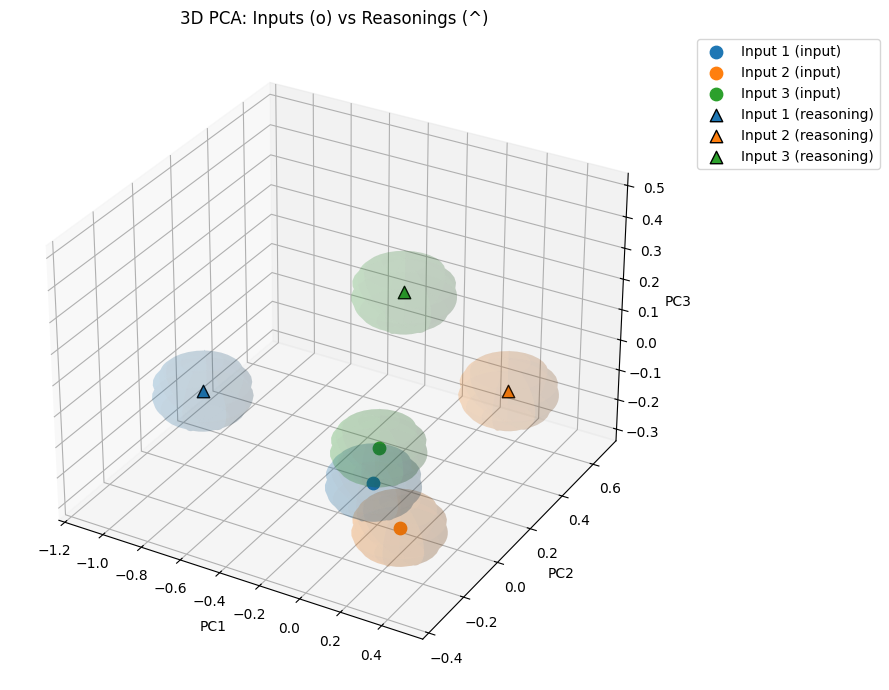

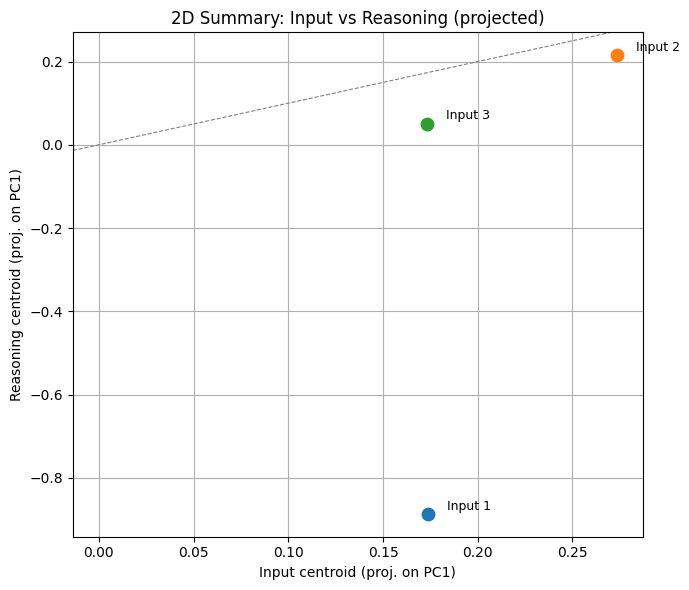

Saved plots to 'plots/' directory:
- plots/inputs_reasonings_3d.png
- plots/inputs_reasonings_2d_summary.png


In [15]:
"""
Multimodal reasoning visualization pipeline
- Encodes inputs + reasoning with SentenceTransformer (384d)
- Reduces to 3D via PCA
- 3D scatter + translucent ellipsoids per (input, reasoning)
- Summary 2D plot: X = input centroid (projected scalar), Y = reasoning centroid (projected scalar)
"""

from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy import linalg
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import os

# -------------------------
# Replace these strings with your actual text blocks
# -------------------------
inputs = [
    {
        "name": "Input 1",
        "audio_text": "Hello, can you explain the Law of Conservation of Energy?",
        "text": "Please describe it in simple words.",
        "reasoning": """Imagine energy as a fundamental "stuff" that fills our universe, but it's not like a solid object; it's more like a versatile, shapeshifting essence...
        (paste full reasoning text here)"""
    },
    {
        "name": "Input 2",
        "audio_text": "First, define the Law of Conservation of Energy.",
        "text": "Explain with formula",
        "reasoning": """The law of conservation of energy dictates that within an isolated system, the total amount of energy remains constant...
        (paste full reasoning text here)"""
    },
    {
        "name": "Input 3",
        "audio_text": "What does the Law of Conservation of Energy mean?",
        "text": "Summarize the concept in one sentence.",
        "reasoning": """The law of conservation of energy describes how energy behaves within a contained space...
        (paste full reasoning text here)"""
    }
]

# -------------------------
# 1) Build text to encode
# We'll encode (audio_text + text) as a single "input" string per item,
# and encode reasoning separately.
# -------------------------
input_texts = [f"{it['audio_text']} {it['text']}" for it in inputs]
reasoning_texts = [it['reasoning'] for it in inputs]

# -------------------------
# 2) Encode with SentenceTransformer to 384-D
# -------------------------
model = SentenceTransformer('all-MiniLM-L6-v2')  # will download if not cached
enc_inputs = model.encode(input_texts, convert_to_numpy=True, show_progress_bar=True)
enc_reasonings = model.encode(reasoning_texts, convert_to_numpy=True, show_progress_bar=True)

# enc_inputs.shape = (3, 384), enc_reasonings.shape = (3, 384)

# -------------------------
# 3) Combine and reduce to 3D using PCA
# We fit PCA on the union so that the reduced 3D spaces are comparable.
# -------------------------
X_union = np.vstack([enc_inputs, enc_reasonings])  # shape (6, 384)
pca = PCA(n_components=3)
X3 = pca.fit_transform(X_union)  # shape (6, 3)

# split back
inputs_3d = X3[:len(inputs), :]            # 3 x 3
reasonings_3d = X3[len(inputs):, :]        # 3 x 3

# -------------------------
# 4) 3D scatter plot with ellipsoids (showing spread / region)
# -------------------------
def plot_ellipsoid(ax, center, cov, n_std=1.0, facecolor='C0', alpha=0.2):
    """
    Draws an ellipsoid corresponding to covariance 'cov' centered at 'center'.
    n_std: how many standard deviations to scale the ellipsoid.
    """
    U, s, _ = np.linalg.svd(cov)
    radii = n_std * np.sqrt(s)

    u = np.linspace(0.0, 2.0 * np.pi, 30)
    v = np.linspace(0.0, np.pi, 30)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    sphere = np.stack([x.ravel(), y.ravel(), z.ravel()])

    ellipsoid = (U @ np.diag(radii)) @ sphere
    ellipsoid = ellipsoid.reshape(3, x.shape[0], x.shape[1])

    ax.plot_surface(ellipsoid[0] + center[0],
                    ellipsoid[1] + center[1],
                    ellipsoid[2] + center[2],
                    rstride=4, cstride=4, linewidth=0, color=facecolor, alpha=alpha)

# Use a small covariance (or global covariance) so ellipsoids visible
global_cov = np.cov(X3.T) + 1e-6 * np.eye(3)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
colors_in = ['C0', 'C1', 'C2']
colors_rg = ['C0', 'C1', 'C2']

# Plot input points
for i, c in enumerate(inputs_3d):
    ax.scatter(c[0], c[1], c[2], marker='o', s=80, color=colors_in[i], label=f"{inputs[i]['name']} (input)")
    plot_ellipsoid(ax, c, global_cov * 0.1, n_std=1.5, facecolor=colors_in[i], alpha=0.15)

# Plot reasoning points
for i, r in enumerate(reasonings_3d):
    ax.scatter(r[0], r[1], r[2], marker='^', s=80, color=colors_rg[i], edgecolor='k', label=f"{inputs[i]['name']} (reasoning)")
    plot_ellipsoid(ax, r, global_cov * 0.12, n_std=1.5, facecolor=colors_rg[i], alpha=0.12)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA: Inputs (o) vs Reasonings (^)")
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/inputs_reasonings_3d.png", dpi=200, bbox_inches='tight')
plt.show()

# -------------------------
# 5) Create summary 2D plot as requested:
# Compute 1D PCA on the 3D reduced data (so PC1 is 3-dim) and project centroids onto it.
# -------------------------

# Fit 1D PCA on the already reduced 3D points (union)
pca_1d = PCA(n_components=1)
pca_1d.fit(X3)   # X3 is shape (6,3)

pc1 = pca_1d.components_[0]  # shape (3,)

# project to 1D scalar
input_scalars = inputs_3d @ pc1        # (3,)
reasoning_scalars = reasonings_3d @ pc1  # (3,)

# Plot (X = input_scalar, Y = reasoning_scalar)
plt.figure(figsize=(7,6))
for i, it in enumerate(inputs):
    x = input_scalars[i]
    y = reasoning_scalars[i]
    plt.scatter(x, y, s=80, label=it['name'])
    plt.text(x + 0.01, y + 0.01, it['name'], fontsize=9)

plt.axline((0,0), slope=1, color='gray', linestyle='--', linewidth=0.8)  # reference
plt.xlabel("Input centroid (proj. on PC1)")
plt.ylabel("Reasoning centroid (proj. on PC1)")
plt.title("2D Summary: Input vs Reasoning (projected)")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/inputs_reasonings_2d_summary.png", dpi=200, bbox_inches='tight')
plt.show()

print("Saved plots to 'plots/' directory:")
print("- plots/inputs_reasonings_3d.png")
print("- plots/inputs_reasonings_2d_summary.png")
